# Walking through AlphaStar Unplugged data

This notebook follows the data path used by AlphaStar Unplugged:

```text
Blizzard replay-pack ZIP → .SC2Replay files → converter → .tfrecord files → learner batches
```

The ZIP and `.SC2Replay` files are genuine human-game source data. AlphaStar cannot train on them directly: the PySC2 converter must replay each game with the matching StarCraft II binary and emit tensors in TFRecord format.

## 1. Locate local data

The cells below deliberately never print credential values from `.env`.

In [1]:
from pathlib import Path
import os

# Change this if you keep data outside the repository.
REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_ROOT = REPO_ROOT / 'local_data' / 'replays'
ARCHIVES = DATA_ROOT / 'archives'

print('Repository:', REPO_ROOT)
print('Data root:', DATA_ROOT)
for path in sorted(DATA_ROOT.rglob('*')):
    if path.is_file():
        print(f'{path.relative_to(REPO_ROOT)}  ({path.stat().st_size / 2**20:.1f} MiB)')

Repository: /Users/johnnylee/PycharmProjects/alphastar
Data root: /Users/johnnylee/PycharmProjects/alphastar/local_data/replays
local_data/replays/4.9.2/sample/00011f6a1673a39e428daa797ea8fd46973af248b27ca342f5756b98c463f64d.SC2Replay  (0.1 MiB)
local_data/replays/4.9.2/sample/000f7233f62ad7bc03f4334c9b59c4b1017205de80880133b2fd171ce555b629.SC2Replay  (0.1 MiB)
local_data/replays/4.9.2/sample/0016ce631b01cb4de6a7f7e8414e43f5d1f11c521f3d1cff93e4e89f14e17532.SC2Replay  (0.1 MiB)
local_data/replays/archives/4.9.2.74741-20190619_105810-1.zip  (346.9 MiB)
local_data/replays/archives/4.9.2.74741-20190621_101121-3.zip  (4.8 MiB)
local_data/replays/offline-debug.csv  (0.0 MiB)


## 2. Inspect a replay-pack archive

A replay pack is a ZIP archive containing many `.SC2Replay` files. Listing it is a fast way to verify a download and see the opaque replay IDs used by Blizzard.

In [2]:
import zipfile

archives = sorted(ARCHIVES.glob('*.zip'))
if not archives:
    raise FileNotFoundError(f'No replay ZIP found under {ARCHIVES}')

archive = archives[0]
replay_names = []
archive_ready = zipfile.is_zipfile(archive)
if not archive_ready:
    size_mib = archive.stat().st_size / 2**20
    print(f'Archive download is still in progress ({size_mib:.1f} MiB downloaded).')
    print('Run this cell again after the download completes and the file becomes a valid ZIP.')
else:
    with zipfile.ZipFile(archive) as zf:
        replay_names = [name for name in zf.namelist() if name.endswith('.SC2Replay')]
    print('Archive:', archive.name)
    print('Replay files:', len(replay_names))
    print('First 10 replay IDs:')
    print(*replay_names[:10], sep='\n')

Archive: 4.9.2.74741-20190619_105810-1.zip
Replay files: 10000
First 10 replay IDs:
00011f6a1673a39e428daa797ea8fd46973af248b27ca342f5756b98c463f64d.SC2Replay
000f7233f62ad7bc03f4334c9b59c4b1017205de80880133b2fd171ce555b629.SC2Replay
0016ce631b01cb4de6a7f7e8414e43f5d1f11c521f3d1cff93e4e89f14e17532.SC2Replay
001b8e04f69a32bf3080322492d1a102c4dbe5ba73988256eaa8b57fa72b80bf.SC2Replay
001d509aa3fc90c8e637fe325c2e94468aa89599ac830f5259f27ee1ea207b21.SC2Replay
002a95a6b7ba40dc5ac148472c0eb29f89c73de8560f2def790e45188fb57e04.SC2Replay
002b418c230ce9622e41b3edf23dca5b7315cf53df772a9202d5f8db35d9ae54.SC2Replay
002c46419df7ddd0c05d72b3b0cb371c1f08aa1e42a9254a0e56c5a2bf9af7ab.SC2Replay
002ec9d3fc3952340fd42b487a382fdd9dd2682ce9ffa8ec7b298cbed8b2ec8e.SC2Replay
00304a33642674dabbf54b772b29f0f4867305a5f6206340724068e3924ad2c2.SC2Replay


## 3. Extract a small sample

Extract just a few raw replays first. A full archive can contain thousands of games, so keeping this small makes exploration quick.

In [3]:
from pathlib import PurePosixPath

RAW_REPLAY_DIR = DATA_ROOT / '4.9.2' / 'sample'
if not archive_ready:
    print('Skipping extraction until the archive download completes.')
else:
    RAW_REPLAY_DIR.mkdir(parents=True, exist_ok=True)
    sample_names = replay_names[:3]
    with zipfile.ZipFile(archive) as zf:
        for name in sample_names:
            target = RAW_REPLAY_DIR / PurePosixPath(name).name
            if not target.exists():
                with zf.open(name, pwd=b'iagreetotheeula') as source, target.open('wb') as destination:
                    destination.write(source.read())
    for replay in sorted(RAW_REPLAY_DIR.glob('*.SC2Replay')):
        print(replay.name, f'{replay.stat().st_size / 2**20:.2f} MiB')

00011f6a1673a39e428daa797ea8fd46973af248b27ca342f5756b98c463f64d.SC2Replay 0.12 MiB
000f7233f62ad7bc03f4334c9b59c4b1017205de80880133b2fd171ce555b629.SC2Replay 0.13 MiB
0016ce631b01cb4de6a7f7e8414e43f5d1f11c521f3d1cff93e4e89f14e17532.SC2Replay 0.10 MiB


## 4. Raw replay EDA

This examines source `.SC2Replay` data before converter processing. It samples 50 games for metadata and scans all archive entries for file-size statistics.

In [4]:
import json, random
import mpyq
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
metadata_rows = []
with zipfile.ZipFile(archive) as zf:
    sizes_kib = pd.Series([info.file_size / 1024 for info in zf.infolist() if info.filename.endswith('.SC2Replay')])
    for name in random.sample(replay_names, k=min(50, len(replay_names))):
        with zf.open(name, pwd=b'iagreetotheeula') as member:
            files = mpyq.MPQArchive(member).extract()
        game = json.loads(files[b'replay.gamemetadata.json'])
        players = game.get('Players', [])
        valid_mmrs = [p.get('MMR') for p in players if 0 <= p.get('MMR', -1) <= 10000]
        metadata_rows.append({'replay_id': Path(name).stem[:12], 'map': game.get('Title'), 'duration_s': game.get('Duration'), 'player_1': players[0].get('AssignedRace') if len(players) > 0 else None, 'player_2': players[1].get('AssignedRace') if len(players) > 1 else None, 'mean_mmr': sum(valid_mmrs) / len(valid_mmrs) if valid_mmrs else None, 'mean_apm': sum(p.get('APM', 0) for p in players) / len(players) if players else None})
eda = pd.DataFrame(metadata_rows)
print(f'Archive has {len(sizes_kib):,} replays.')
display(sizes_kib.describe(percentiles=[.05, .25, .5, .75, .95]).to_frame('replay_size_kib'))
display(eda.head(10))

Archive has 10,000 replays.


,replay_size_kib
count,10000.000000
mean,71.099956
std,35.625418
min,27.645508
5%,28.466797
25%,45.134766
50%,64.136230
75%,89.664307
95%,136.845898
max,404.282227


,replay_id,map,duration_s,player_1,player_2,mean_mmr,mean_apm
0,2e3f8ae632cd,Croisement de Kairos EC,539,Prot,Terr,2135.0,111.5
1,0a819892ce6a,King's Cove LE,817,Terr,Zerg,2746.5,65.5
2,71a2e2b6fe52,썬더버드 - 래더,1481,Prot,Terr,3337.0,118.5
3,64f44ff8b1c3,Cyber Forest LE,340,Prot,Zerg,4237.5,219.0
4,5c5d09f07ffa,Acropolis LE,5,Terr,Zerg,5226.5,272.5
5,3a694c4d157b,Acropolis EC,457,Terr,Prot,3250.5,119.5
6,2a933df6f198,Kairos Junction LE,789,Zerg,Prot,3893.0,164.0
7,e31d9cb7244f,凯罗斯中转站-天梯版,459,Prot,Terr,2614.5,111.5
8,24174c487d5d,Acropolis EC,889,Prot,Terr,3154.0,132.5
9,f77cbae64a74,Cyber Forest LE,903,Prot,Prot,3479.0,104.5


/var/folders/v7/4r0w4bz13n53t7r_hr77cp1w0000gn/T/ipykernel_68301/927570215.py:8: UserWarning: Glyph 22269 (\N{CJK UNIFIED IDEOGRAPH-56FD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/v7/4r0w4bz13n53t7r_hr77cp1w0000gn/T/ipykernel_68301/927570215.py:8: UserWarning: Glyph 29579 (\N{CJK UNIFIED IDEOGRAPH-738B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/v7/4r0w4bz13n53t7r_hr77cp1w0000gn/T/ipykernel_68301/927570215.py:8: UserWarning: Glyph 34255 (\N{CJK UNIFIED IDEOGRAPH-85CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/v7/4r0w4bz13n53t7r_hr77cp1w0000gn/T/ipykernel_68301/927570215.py:8: UserWarning: Glyph 23453 (\N{CJK UNIFIED IDEOGRAPH-5B9D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/v7/4r0w4bz13n53t7r_hr77cp1w0000gn/T/ipykernel_68301/927570215.py:8: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from font(s) DejaVu Sans.
  p

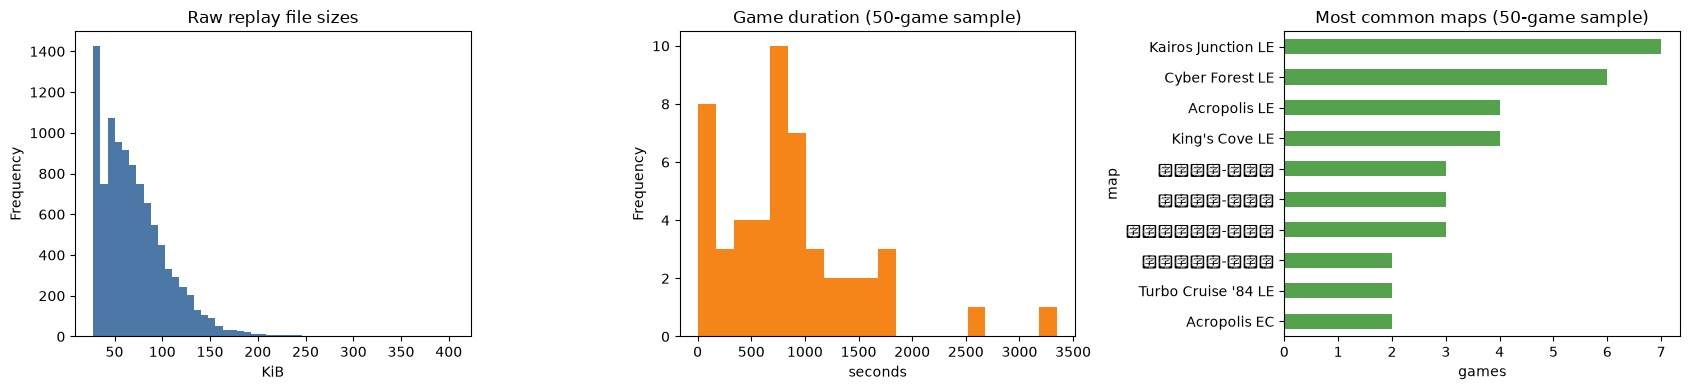

player_2,Prot,Terr,Zerg
player_1,,,
Prot,3,7,4
Terr,5,8,6
Zerg,7,3,7


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sizes_kib.plot.hist(bins=50, ax=axes[0], color='#4C78A8')
axes[0].set(title='Raw replay file sizes', xlabel='KiB')
eda['duration_s'].plot.hist(bins=20, ax=axes[1], color='#F58518')
axes[1].set(title='Game duration (50-game sample)', xlabel='seconds')
eda['map'].value_counts().head(10).sort_values().plot.barh(ax=axes[2], color='#54A24B')
axes[2].set(title='Most common maps (50-game sample)', xlabel='games')
plt.tight_layout(); plt.show()
display(pd.crosstab(eda['player_1'], eda['player_2']))

## 5. What the converter produces

`generate_dataset.py` runs the SC2 engine against each replay and writes TFRecords. Each player in a two-player game becomes a separate training episode. The conceptual record is:

```python
{
  'step_type': [...],
  'observation': {
      'raw_units': [time, up_to_512_units, 46_features],
      'minimap_height_map': [time, 128, 128],
      'player': [time, player_features],
      'action/function': [time],
      'action/unit_tags': [time, 64],
      'action/world': [time],
  },
}
```

The action fields are the human's actions. During behavior cloning, the network predicts them from the observations and receives weighted cross-entropy loss.

## 6. Inspect converted TFRecords

Run this after conversion. It recreates the schema directly from the repository converter settings, decodes one episode, and prints feature shapes plus small value slices.

In [6]:
CONVERTED_DIR = DATA_ROOT / 'converted' / '4.9.2' / 'sample'
tfrecords = sorted(CONVERTED_DIR.glob('*.tfrecord'))
if not tfrecords:
    print(f'No TFRecords found under {CONVERTED_DIR}. Convert the sample replays first; see the next cell.')
else:
    # Requires the project's dependencies: pip install -r requirements.txt
    from alphastar.unplugged.configs.alphastar_supervised import SUPERVISED_CONVERTER_SETTINGS
    from alphastar.unplugged.data import util as data_util
    from pysc2.env import converted_env
    import tensorflow as tf
    obs_spec, _ = converted_env.get_environment_spec(SUPERVISED_CONVERTER_SETTINGS)
    features = data_util.get_dataset_specs(obs_spec)
    coder = data_util.TFExampleCoder(features=features, compress=True)
    example = next(iter(tf.data.TFRecordDataset([str(tfrecords[0])])))
    episode = coder.decode(example)
    def walk(value, prefix=''):
        if isinstance(value, dict):
            for key, child in value.items():
                yield from walk(child, f'{prefix}/{key}' if prefix else key)
        else:
            yield prefix, value
    for name, value in walk(episode):
        array = value.numpy()
        print(f'{name:55} shape={str(array.shape):18} dtype={array.dtype} first={array.reshape(-1)[:8]}')

No TFRecords found under /Users/johnnylee/PycharmProjects/alphastar/local_data/replays/converted/4.9.2/sample. Convert the sample replays first; see the next cell.


## 7. Convert the sample replays

This repository was tested on Linux. Conversion needs a local StarCraft II **4.9.2** binary matching the replay version, plus the Python dependencies. The command below is shown for reference; run it in a compatible Linux setup after creating a partition file.

```bash
python alphastar/unplugged/data/generate_partitions.py \
  --sc2_replay_path=local_data/replays/4.9.2/sample \
  --converted_path=local_data/replays/converted/4.9.2/sample \
  --num_partitions=1 \
  --partition_path=local_data/replays/partitions/4.9.2/sample

python alphastar/unplugged/data/generate_dataset.py \
  --sc2_replay_path=local_data/replays/4.9.2/sample \
  --converted_path=local_data/replays/converted/4.9.2/sample \
  --partition_file=local_data/replays/partitions/4.9.2/sample/partition_0 \
  --converter_settings=alphastar/unplugged/configs/alphastar_supervised_converter_settings.pbtxt \
  --logtostderr
```

## 8. From episode to learner batch

The data source flattens episodes into fixed-length, shuffled sequences. With `batch_size=4` and `unroll_len=3`, raw-unit input has shape `(4, 3, 512, 46)`. The learner sends those batches through the policy; its loss compares output logits with `behaviour_features/action/*`.

Relevant implementation files:

- `alphastar/unplugged/data/data_source.py` — TFRecord episodes → batches.
- `alphastar/unplugged/data/util.py` — feature schema and learner-input conversion.
- `alphastar/unplugged/losses/supervised.py` — weighted action cross-entropy.
- `alphastar/unplugged/modules/learner.py` — forward pass and parameter update.

## 9. Train a model

The first command below is a **smoke test**. It trains the minimal `alphastar.dummy` architecture on synthetic tensors for 16 frames. It checks that JAX, the optimizer, loss, checkpointing, and training loop can work together—but it does not learn StarCraft strategy.

The second command is the real offline behavior-cloning run, which becomes available only after converting raw replays into TFRecords.

In [7]:
import importlib.util

required = ['jax', 'haiku', 'optax', 'tensorflow', 'pysc2', 'acme', 'chex']
availability = {package: importlib.util.find_spec(package) is not None for package in required}
availability

# AlphaStar was tested upstream with Python 3.9 on Linux.
# Use a compatible environment for training if any dependency above is False.

{'jax': False,
 'haiku': False,
 'optax': False,
 'tensorflow': False,
 'pysc2': False,
 'acme': False,
 'chex': False}

In [8]:
# Opt-in: set RUN_DUMMY_TRAINING = True, then run this cell.
# It launches a separate process so notebook memory stays clean.
RUN_DUMMY_TRAINING = True

import subprocess, sys

# The repository is tested with Python 3.9. This dedicated environment is
# created by the walkthrough setup; fall back to the active kernel only if absent.
ALPHASTAR_PYTHON = REPO_ROOT / '.conda-alphastar' / 'bin' / 'python'
if not ALPHASTAR_PYTHON.exists():
    ALPHASTAR_PYTHON = Path(sys.executable)
print('Training interpreter:', ALPHASTAR_PYTHON)

dummy_command = [
    str(ALPHASTAR_PYTHON), 'alphastar/unplugged/scripts/train.py',
    '--config=alphastar/unplugged/configs/alphastar_supervised.py:alphastar.dummy',
    '--config.train.max_number_of_frames=16',
    '--config.train.learner_kwargs.batch_size=4',
    '--config.train.datasource.kwargs.shuffle_buffer_size=16',
    '--config.train.optimizer_kwargs.lr_frames_before_decay=4',
    '--config.train.learner_kwargs.unroll_len=3',
    '--config.train.datasource.name=DummyDataSource',
    '--config.train.learner_kwargs.log_to_csv=False',
]
print(' '.join(dummy_command))
if RUN_DUMMY_TRAINING:
    completed = subprocess.run(dummy_command, cwd=REPO_ROOT, text=True, capture_output=True)
    print(completed.stdout)
    print(completed.stderr)
    if completed.returncode:
        print(f'Training failed with exit code {completed.returncode}. The error above identifies the missing/incompatible dependency.')
else:
    print('Dry run only. Set RUN_DUMMY_TRAINING = True to launch the 16-frame smoke test.')

Training interpreter: /Users/johnnylee/PycharmProjects/alphastar/.conda-alphastar/bin/python
/Users/johnnylee/PycharmProjects/alphastar/.conda-alphastar/bin/python alphastar/unplugged/scripts/train.py --config=alphastar/unplugged/configs/alphastar_supervised.py:alphastar.dummy --config.train.max_number_of_frames=16 --config.train.learner_kwargs.batch_size=4 --config.train.datasource.kwargs.shuffle_buffer_size=16 --config.train.optimizer_kwargs.lr_frames_before_decay=4 --config.train.learner_kwargs.unroll_len=3 --config.train.datasource.name=DummyDataSource --config.train.learner_kwargs.log_to_csv=False

Traceback (most recent call last):
  File "/Users/johnnylee/PycharmProjects/alphastar/alphastar/unplugged/scripts/train.py", line 56, in <module>
    from acme.jax import utils
  File "/Users/johnnylee/PycharmProjects/alphastar/.conda-alphastar/lib/python3.9/site-packages/acme/jax/utils.py", line 190, in <module>
    devices: Optional[Sequence[jax.xla.Device]] = None,
  File "/Users/joh

In [9]:
# Configure the generated TFRecord locations, then use this command for real offline training.
# `paths.py` must define BASE_PATH and RELATIVE_PATHS; see paths.py.template.
PATHS_FILE = REPO_ROOT / 'local_data' / 'paths.py'
real_command = [
    str(ALPHASTAR_PYTHON), 'alphastar/unplugged/scripts/train.py',
    '--config=alphastar/unplugged/configs/alphastar_supervised.py:alphastar.lite',
    f'--config.train.datasource.kwargs.dataset_paths_fname={PATHS_FILE}',
    '--config.train.datasource.kwargs.replay_versions=("4.9.2",)',
]
print(' '.join(real_command))
if not PATHS_FILE.exists():
    print(f'Not runnable yet: create {PATHS_FILE} after TFRecord conversion.')
else:
    print('Paths file found. Review batch size and max_number_of_frames before launching this long-running job.')

/Users/johnnylee/PycharmProjects/alphastar/.conda-alphastar/bin/python alphastar/unplugged/scripts/train.py --config=alphastar/unplugged/configs/alphastar_supervised.py:alphastar.lite --config.train.datasource.kwargs.dataset_paths_fname=/Users/johnnylee/PycharmProjects/alphastar/local_data/paths.py --config.train.datasource.kwargs.replay_versions=("4.9.2",)
Not runnable yet: create /Users/johnnylee/PycharmProjects/alphastar/local_data/paths.py after TFRecord conversion.


### Reading training output

The learner reports `loss`, `gradient_norm`, parameter norms, and a separate cross-entropy/argmax-accuracy metric for each action component. Loss decreasing on the dummy test only proves the code path works; use held-out converted replays and environment evaluation to assess a real model.